In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.executescript('''
    CREATE TABLE Departamentos (
        id_depto INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL UNIQUE
    );

    CREATE TABLE Empleados (
        id_emp INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        edad INTEGER CHECK(edad >= 18),
        id_depto INTEGER,
        FOREIGN KEY(id_depto) REFERENCES Departamentos(id_depto)
    );
''')

print("Modelo Relacional creado exitosamente.")

Modelo Relacional creado exitosamente.


In [2]:
try:
    cursor.execute("INSERT INTO Departamentos VALUES (1,'Sistemas')")
    cursor.execute("INSERT INTO Empleados VALUES (1,'Juan',25,1)")
    conn.commit()
    print("Inserción exitosa")
except Exception as e:
    print(e)

Inserción exitosa


In [3]:
try:
    cursor.execute("INSERT INTO Empleados VALUES (2,'Pedro',16,1)")
    conn.commit()
except Exception as e:
    print("Error:", e)

Error: CHECK constraint failed: edad >= 18


In [5]:
try:
    cursor.execute("INSERT INTO Empleados VALUES (3,'Maria',30,99)")
    conn.commit()
except Exception as e:
    print("Error:", e)

Error: UNIQUE constraint failed: Empleados.id_emp


In [6]:
import json

catalogo_json = """
[
    {"id": "p1", "categoria": "Electronica", "nombre": "Laptop X", "specs": {"ram": "16GB", "cpu": "i7"}},
    {"id": "p2", "categoria": "Ropa", "nombre": "Camiseta Polo", "detalles": {"talla": "M", "color": "Azul", "material": "Algodon"}},
    {"id": "p3", "categoria": "Hogar", "nombre": "Licuadora", "potencia_watts": 800, "garantia_anos": 2}
]
"""

coleccion_productos = json.loads(catalogo_json)
print(coleccion_productos)

[{'id': 'p1', 'categoria': 'Electronica', 'nombre': 'Laptop X', 'specs': {'ram': '16GB', 'cpu': 'i7'}}, {'id': 'p2', 'categoria': 'Ropa', 'nombre': 'Camiseta Polo', 'detalles': {'talla': 'M', 'color': 'Azul', 'material': 'Algodon'}}, {'id': 'p3', 'categoria': 'Hogar', 'nombre': 'Licuadora', 'potencia_watts': 800, 'garantia_anos': 2}]


In [7]:
for producto in coleccion_productos:
    if "detalles" in producto and "color" in producto["detalles"]:
        print(producto["nombre"])

Camiseta Polo


In [8]:
total = 0
contador = 0

for producto in coleccion_productos:
    if "garantia_anos" in producto:
        total += producto["garantia_anos"]
        contador += 1

if contador > 0:
    print("Promedio garantia:", total/contador)
else:
    print("No hay datos")

Promedio garantia: 2.0


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tickets = [
    "La pantalla de mi laptop esta rota y no enciende",
    "El teclado funciona bien pero la bateria se descarga rapido",
    "Mi bateria esta rota, necesito un reemplazo urgente",
    "No puedo instalar el software de facturacion"
]

vectorizer = TfidfVectorizer()
matriz_tfidf = vectorizer.fit_transform(tickets)

print(vectorizer.get_feature_names_out())

['bateria' 'bien' 'de' 'descarga' 'el' 'enciende' 'esta' 'facturacion'
 'funciona' 'instalar' 'la' 'laptop' 'mi' 'necesito' 'no' 'pantalla'
 'pero' 'puedo' 'rapido' 'reemplazo' 'rota' 'se' 'software' 'teclado' 'un'
 'urgente']


In [10]:
consulta = ["bateria rota"]

vector_busqueda = vectorizer.transform(consulta)

similitud = cosine_similarity(vector_busqueda, matriz_tfidf)

resultados = list(enumerate(similitud[0]))

resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)

for i, score in resultados_ordenados:
    print(tickets[i], "->", score)

Mi bateria esta rota, necesito un reemplazo urgente -> 0.4377912310861148
La pantalla de mi laptop esta rota y no enciende -> 0.21490411836213663
El teclado funciona bien pero la bateria se descarga rapido -> 0.18724231956240414
No puedo instalar el software de facturacion -> 0.0


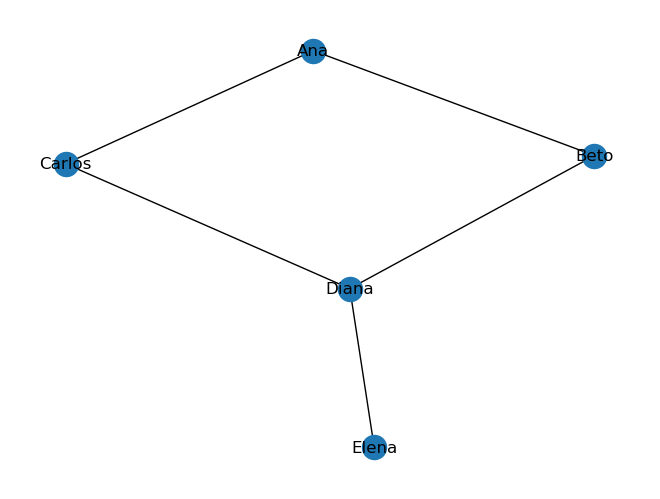

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

usuarios = ["Ana","Beto","Carlos","Diana","Elena"]
G.add_nodes_from(usuarios)

G.add_edges_from([
("Ana","Beto"),
("Ana","Carlos"),
("Beto","Diana"),
("Carlos","Diana"),
("Diana","Elena")
])

nx.draw(G, with_labels=True)
plt.show()

In [2]:
# Amigos directos de Ana
print("Amigos directos de Ana:")
print(list(G.neighbors("Ana")))

Amigos directos de Ana:
['Beto', 'Carlos']


In [3]:
amigos = set(G.neighbors("Ana"))
recomendaciones = set()

for amigo in amigos:
    amigos_de_amigos = set(G.neighbors(amigo))
    recomendaciones.update(amigos_de_amigos)

# quitar amigos directos y a Ana
recomendaciones = recomendaciones - amigos - {"Ana"}

print("Recomendaciones para Ana:")
print(recomendaciones)

Recomendaciones para Ana:
{'Diana'}


## Conclusiones del Laboratorio

### Fase 1 – Modelo Relacional
¿Por qué dejar la validación de la edad solo en el frontend (página web) es peligroso y cómo la base de datos SQL nos salvó?
Dejar la validación únicamente en el frontend es peligroso porque los usuarios pueden enviar datos directamente al servidor sin pasar por la página web. Las restricciones de la base de datos como PRIMARY KEY, CHECK y FOREIGN KEY protegen la integridad de los datos evitando que se almacene información inválida.

### Fase 2 – Modelos Semiestructurados
¿Qué pasaría con el rendimiento si intentáramos forzar el catálogo JSON dentro de una tabla SQL estricta?
Si el catálogo JSON se almacenara en una base de datos SQL estricta, sería necesario crear muchas columnas o tablas adicionales para manejar los diferentes atributos de cada producto. Esto generaría complejidad y muchos valores nulos. Las bases de datos documentales permiten mayor flexibilidad para datos heterogéneos.

### Fase 3 – Vector Space Model
Explique en sus propias palabras por qué la similitud de coseno encontró el ticket correcto para "bateria rota" mejor que un SELECT * WHERE texto LIKE '%bateria rota%'.
La similitud de coseno permite encontrar documentos relacionados incluso cuando las palabras no aparecen exactamente en el mismo orden. TF-IDF identifica la importancia de cada palabra en los documentos, lo que mejora la relevancia de los resultados comparado con búsquedas simples usando LIKE en SQL.

### Fase 4 – Grafos
¿Por qué los grafos son inherentemente superiores a las tablas relacionales para redes sociales?
Los grafos son más eficientes para representar redes sociales porque las relaciones entre usuarios se modelan directamente como conexiones. Esto permite encontrar relaciones como amigos de amigos de manera rápida sin necesidad de múltiples operaciones JOIN como en bases de datos relacionales.